<a href="https://colab.research.google.com/github/Roxiskil/Python/blob/main/week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
  City_Name River_Name  Pollution_Level  Measurement_Year Contaminant_Index
0    Dundee        Tay               12              2010                 5
1     Perth        Tay               15              2010                 8
2   Newport        Tay               18              2010                13
3     Cupar      Leven               21              2010                21
4   Kinross      Leven               25              2010                34

Average pollution per river:
Tay: 35.777778
Leven: 34.350000
St_Andrews_Burn: 35.400000
Ericht: 36.800000

Most polluted river: Ericht
Average pollution level: 36.80


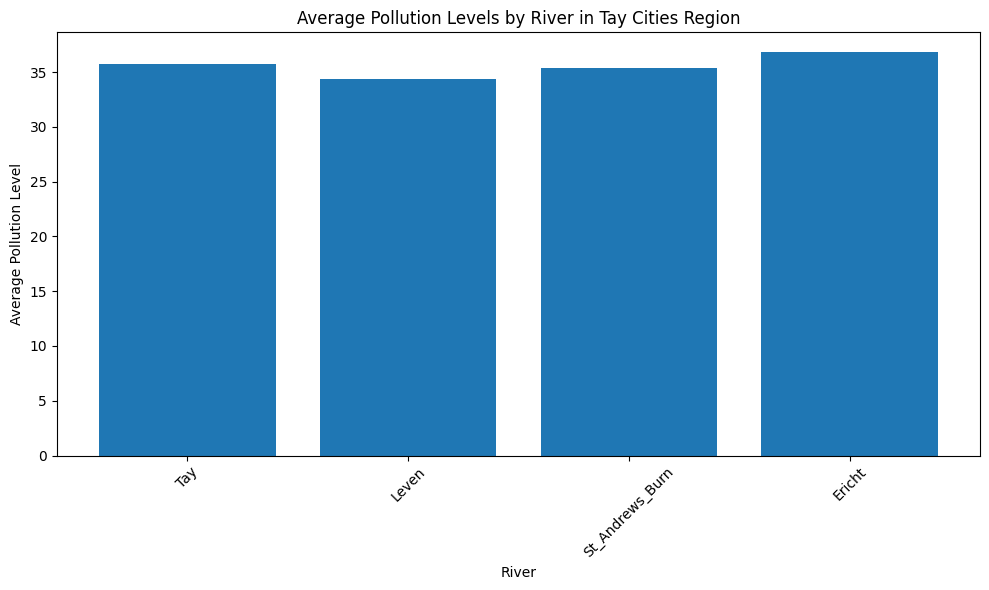

Saved as average_pollution_by_river.csv


In [ ]:
# Practice 1: Recursively calculate average pollution per river and identify the most polluted river
import pandas as pd
import matplotlib.pyplot as plt

#Load csv
data = pd.read_csv("TaySewage.csv")

# Show first rows
print("First 5 rows:")
print(data.head())

#Clean data
data = data.dropna()

#Pollution column should be numeric
data["Pollution_Level"] = pd.to_numeric(data["Pollution_Level"], errors="coerce")

#Drop rows where pollution could not be converted
data = data.dropna(subset=["Pollution_Level"])

#Conver dataframe to list of dictionaries
records = data.to_dict(orient="records")

#Recursive function to calculate average pollution for one river
def avg_pollution_river(records, river_name, index=0, total=0, count=0):
  if index == len(records):
    return total / count if count != 0 else 0
  rec = records[index]

  if rec["River_Name"] == river_name:
    total += rec["Pollution_Level"]
    count += 1

  return avg_pollution_river(records, river_name, index + 1, total, count)

#Get unique rivers
rivers = data["River_Name"].unique()

#Calculate averages recursively
river_avg_pollution = {}
for river in rivers:
  river_avg_pollution[river] = avg_pollution_river(records, river)

#Print results
print("\nAverage pollution per river:")
for river, avg in river_avg_pollution.items():
  print(f"{river}: {avg:2f}")

#Find the most polluted river
most_polluted_river = max(river_avg_pollution, key=river_avg_pollution.get)
print(f"\nMost polluted river: {most_polluted_river}")
print(f"Average pollution level: {river_avg_pollution[most_polluted_river]:.2f}")

#Bar chart
plt.figure(figsize=(10,6))
plt.bar(river_avg_pollution.keys(), river_avg_pollution.values())
plt.xlabel("River")
plt.ylabel("Average Pollution Level")
plt.title("Average Pollution Levels by River in Tay Cities Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Save csv file
result_df = pd.DataFrame(list(river_avg_pollution.items()), columns=["River_Name", "Average_Pollution"])
result_df.to_csv("average_pollution_by_river.csv", index=False)
print("Saved as average_pollution_by_river.csv")

First 5 rows with prediction:
  City_Name  Measurement_Year  Pollution_Level  Predicted_Contaminant
0    Dundee              2010               12                     67
1     Perth              2010               15                     70
2   Newport              2010               18                     73
3     Cupar              2010               21                     76
4   Kinross              2010               25                     80


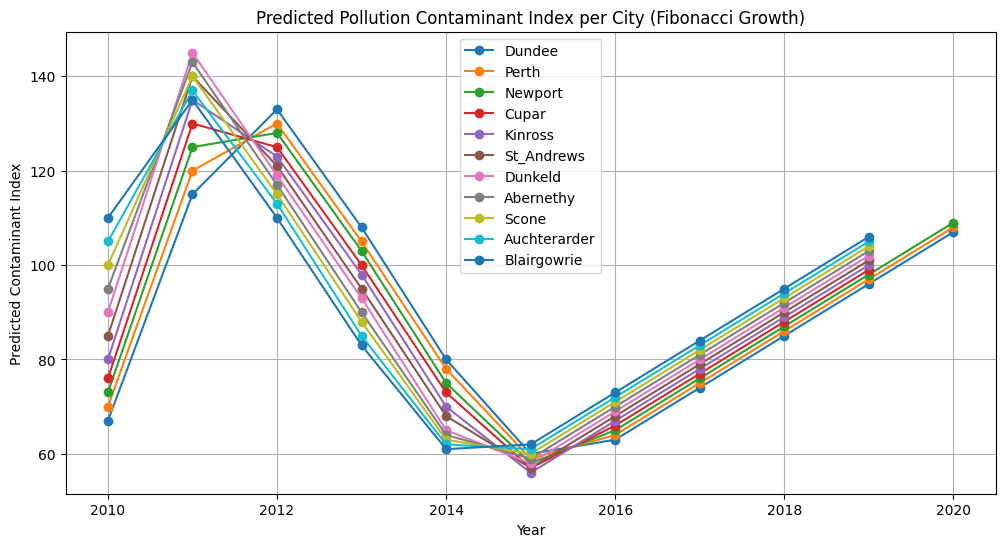

Saved as future_contamination_predictions.csv


In [ ]:
#Use Fibonacci sequence to predict future contaminant indices, then visualise trends
import pandas as pd
import matplotlib.pyplot as plt

#Load csv
data = pd.read_csv("TaySewage.csv")

#Clean data
data = data.dropna()

# Convert important columns to correct types
data["Pollution_Level"] = pd.to_numeric(data["Pollution_Level"], errors="coerce")
data["Measurement_Year"] = pd.to_numeric(data["Measurement_Year"], errors="coerce")

# Remove rows with missing numeric values
data = data.dropna(subset=["Pollution_Level", "Measurement_Year"])

# Make year integer
data["Measurement_Year"] = data["Measurement_Year"].astype(int)

# Fibonacci function with memoization
def fibonacci(n, memo={}):
    if n <= 1:
        return n
    if n in memo:
        return memo[n]
    memo[n] = fibonacci(n - 1, memo) + fibonacci(n - 2, memo)
    return memo[n]

# Use a Fibonacci number as a simple growth factor
fib_value = fibonacci(10)

# Create predicted contaminant index
data["Predicted_Contaminant"] = data["Pollution_Level"] + fib_value

# Show first rows
print("First 5 rows with prediction:")
print(data[["City_Name", "Measurement_Year", "Pollution_Level", "Predicted_Contaminant"]].head())

# Plot line chart for each city
plt.figure(figsize=(12, 6))

for city in data["City_Name"].unique():
    city_data = data[data["City_Name"] == city].sort_values("Measurement_Year")
    plt.plot(city_data["Measurement_Year"], city_data["Predicted_Contaminant"], marker='o', label=city)

plt.xlabel("Year")
plt.ylabel("Predicted Contaminant Index")
plt.title("Predicted Pollution Contaminant Index per City (Fibonacci Growth)")
plt.legend()
plt.grid(True)
plt.show()

#Save csv file
data.to_csv("future_contamination_predictions.csv", index=False)
print("Saved as future_contamination_predictions.csv")



In [ ]:
#Recursively find the most popular beach in a list simulating hierarchical data explolation

import pandas as pd

# Load CSV
data = pd.read_csv("FifeCoastal.csv")   # change name if needed

# Clean data
data = data.dropna()

# Make sure popularity score is numeric
data["Popularity_Score"] = pd.to_numeric(data["Popularity_Score"], errors="coerce")
data = data.dropna(subset=["Popularity_Score"])

# Convert to list of dictionaries
beaches = data.to_dict(orient="records")

# Recursive function to find most popular beach
def most_popular(beach_list, index=0, current_best=None):
    if index == len(beach_list):
        return current_best

    beach = beach_list[index]

    if current_best is None or beach["Popularity_Score"] > current_best["Popularity_Score"]:
        current_best = beach

    return most_popular(beach_list, index + 1, current_best)

# Find result
best_beach = most_popular(beaches)

print("Most Popular Beach in Fife Coastal Region:")
print(f"{best_beach['Beach_Name']} with Popularity Score {best_beach['Popularity_Score']}")

import matplotlib.pyplot as plt

# Sort beaches by popularity
import matplotlib.pyplot as plt


Most Popular Beach in Fife Coastal Region:
StMonans with Popularity Score 92.0


In [ ]:
#Estimate visitor growth for beaches using Fibonacci sequence (predictive modelling). Assume popularity influences growth and visito counts roughly follow Fibonacci ratios

import pandas as pd

# Load CSV
data = pd.read_csv("FifeCoastal.csv")

# Clean data
data = data.dropna()
data["Visitor_Count"] = pd.to_numeric(data["Visitor_Count"], errors="coerce")
data = data.dropna(subset=["Visitor_Count"])
data = data.reset_index(drop=True)

# Fibonacci function
def fibonacci(n, memo={}):
    if n <= 1:
        return n
    if n in memo:
        return memo[n]
    memo[n] = fibonacci(n - 1, memo) + fibonacci(n - 2, memo)
    return memo[n]

results = []

for i, row in data.head(10).iterrows():
    fib_value = fibonacci(i + 5)
    predicted_visitors = int(row["Visitor_Count"]) + fib_value * 100
    results.append({
        "Beach_Name": row["Beach_Name"],
        "Current_Visitors": int(row["Visitor_Count"]),
        "Predicted_Visitors": predicted_visitors
    })

result_df = pd.DataFrame(results)
print(result_df)

       Beach_Name  Current_Visitors  Predicted_Visitors
0            Elie                 5                 505
1  St_Andrews_Bay                 8                 808
2      Kingsbarns                13                1313
3     West_Wemyss                21                2121
4    Dysart_Beach                34                3434
5         Culross                55                5555
6     Burntisland                89                8989
7        Seafield               144               14544
8      Pittenweem               233               23533
9      Anstruther               377               38077


/tmp/ipykernel_611/519592693.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectangle((x - 0.05, y - 0.05), 0.1, 0.1,


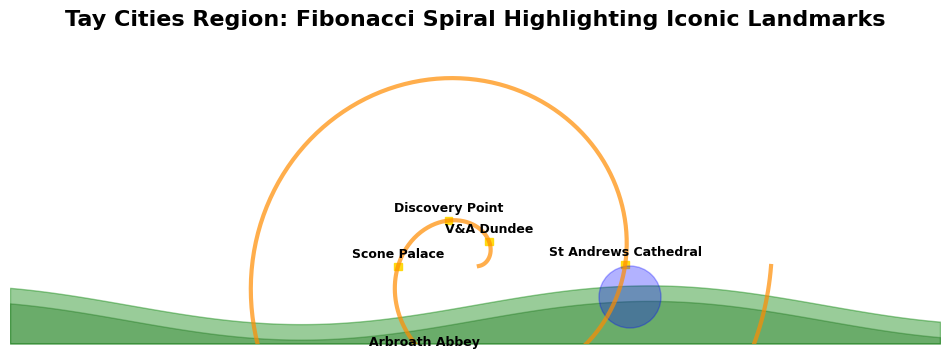

<Figure size 640x480 with 0 Axes>

In [ ]:
# Additional task
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle

#Functions
def fibonacci_spiral(a, b, n_points=500):
    """Generate points for a prominent Fibonacci spiral."""
    theta = np.linspace(0, 4 * np.pi, n_points)
    r = a + b * theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def draw_landmark(ax, x, y, name, color='gold'):
    """Draw a landmark as a small building icon."""
    ax.add_patch(Rectangle((x - 0.05, y - 0.05), 0.1, 0.1,
                           color=color, alpha=0.9, edgecolor='black'))
    ax.text(x, y + 0.08, name, fontsize=9, ha='center', va='bottom', fontweight='bold')

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Minimalist hills in background
x = np.linspace(-6, 6, 600)
y_hills = 0.25 * np.sin(x * 0.7) - 0.5
ax.fill_between(x, y_hills, -1, color='green', alpha=0.4)
ax.fill_between(x, y_hills - 0.2, -1, color='darkgreen', alpha=0.3)

# Prominent Fibonacci spiral
x_s, y_s = fibonacci_spiral(a=0.05, b=0.3, n_points=600)
ax.plot(x_s, y_s, color='darkorange', lw=3, alpha=0.7, label='Fibonacci Spiral')

# Tay Cities Region landmarks
landmarks = [
    {'name': 'V&A Dundee', 'pos': (x_s[50], y_s[50])},
    {'name': 'Discovery Point', 'pos': (x_s[100], y_s[100])},
    {'name': 'Scone Palace', 'pos': (x_s[150], y_s[150])},
    {'name': 'Arbroath Abbey', 'pos': (x_s[200], y_s[200])},
    {'name': 'St Andrews Cathedral', 'pos': (x_s[300], y_s[300])}
]

for lm in landmarks:
    draw_landmark(ax, lm['pos'][0], lm['pos'][1], lm['name'])

# Tay Loch / estuary as water element
loch = Circle((2.0, -0.4), 0.4, color='blue', alpha=0.3)
ax.add_artist(loch)

# Aesthetic tweaks
ax.set_xlim(-6, 6)
ax.set_ylim(-1, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tay Cities Region: Fibonacci Spiral Highlighting Iconic Landmarks",
             fontsize=16, fontweight='bold')

plt.show()

plt.savefig("tay_fibonacci_spiral.png", dpi=300, bbox_inches="tight")

Dataset loaded successfully.

First 5 rows:
  City_Name River_Name  Pollution_Level  Measurement_Year Contaminant_Index
0    Dundee        Tay               12              2010                 5
1     Perth        Tay               15              2010                 8
2   Newport        Tay               18              2010                13
3     Cupar      Leven               21              2010                21
4   Kinross      Leven               25              2010                34

Columns:
['City_Name', 'River_Name', 'Pollution_Level', 'Measurement_Year', 'Contaminant_Index']

Missing values:
City_Name            0
River_Name           0
Pollution_Level      0
Measurement_Year     0
Contaminant_Index    0
dtype: int64

Duplicate rows: 0

Cleaned data preview:
  City_Name River_Name  Pollution_Level  Measurement_Year Contaminant_Index
0    Dundee        Tay               12              2010                 5
1     Perth        Tay               15              2010      

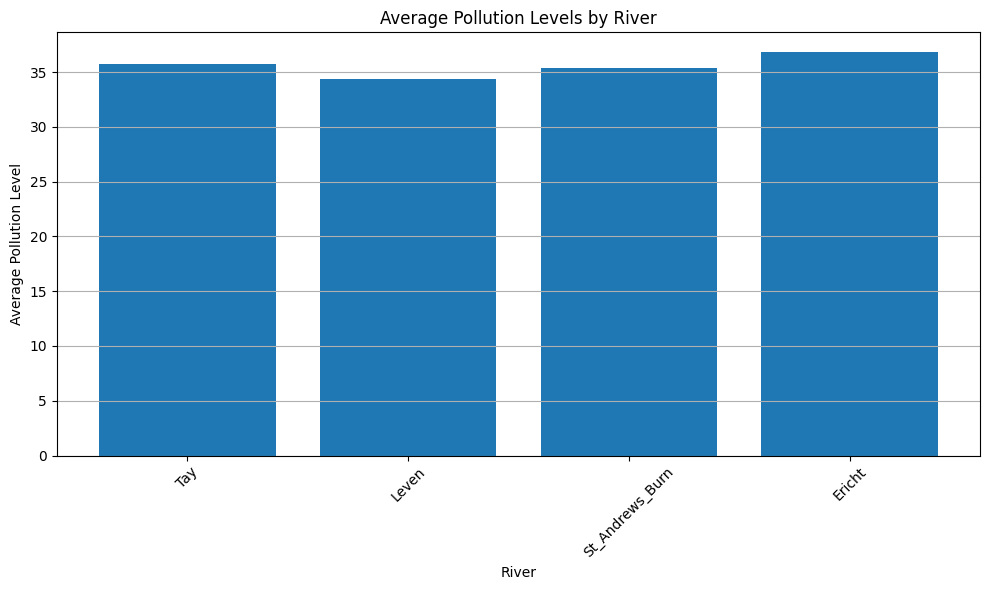

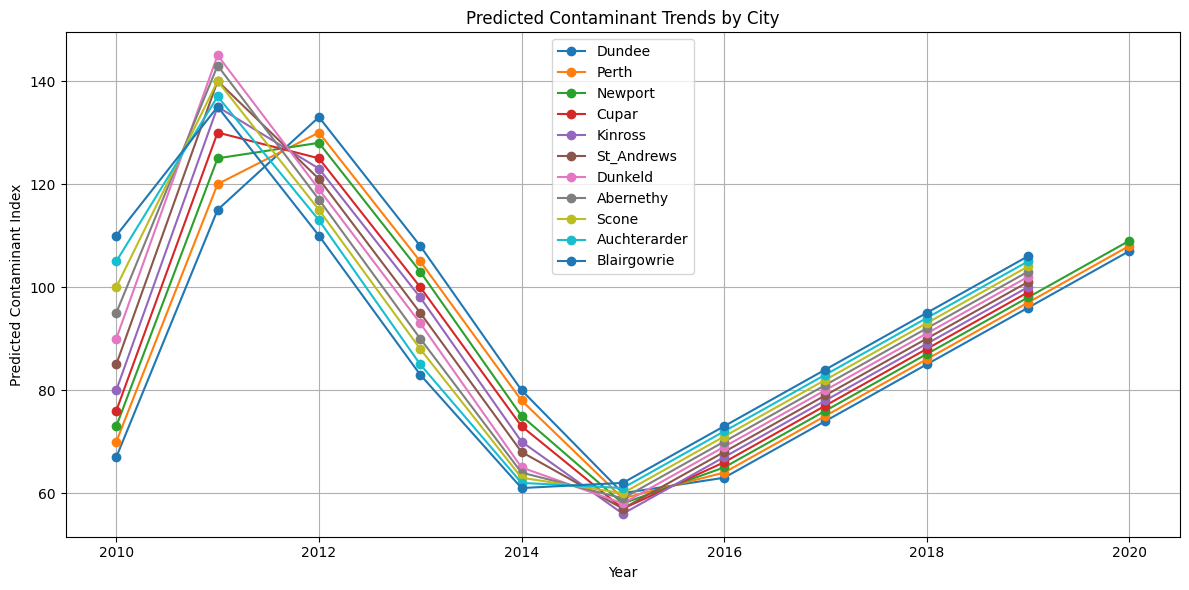

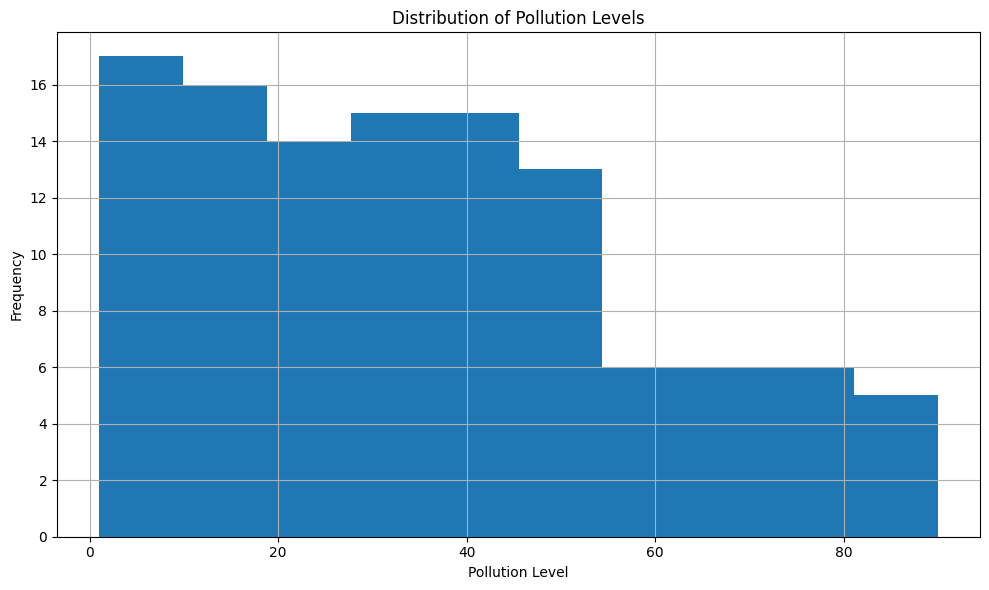


WEEK 7 REPORT SUMMARY

1. The dataset was loaded and validated.
2. Missing values and duplicate rows were checked and removed.
3. Text columns were standardised and numeric columns were converted to correct types.
4. Recursion was used to calculate average pollution levels for each river.
5. The river with the highest average pollution level was Ericht with an average of 36.80.
6. Fibonacci modelling was used to generate a simple predicted contaminant index.
7. Visualisations showed:
   - average pollution by river,
   - predicted contaminant trends by city,
   - distribution of pollution levels.
8. These results can help identify high-risk rivers and cities with rising contamination trends.

Saved report summary as week7_report_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# Submission

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and validate data
def load_data(filename):
    df = pd.read_csv(filename)

    print("Dataset loaded successfully.\n")
    print("First 5 rows:")
    print(df.head())

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    return df

# 2. Clean data
def clean_data(df):
    df = df.copy()

    # Remove duplicates
    df = df.drop_duplicates()

    # Standardise text columns
    for col in ["River_Name", "City_Name"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.title()

    # Convert numeric columns
    for col in ["Pollution_Level", "Measurement_Year"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop rows with missing key values
    required_cols = ["River_Name", "City_Name", "Pollution_Level", "Measurement_Year"]
    df = df.dropna(subset=required_cols)

    # Convert year to integer
    df["Measurement_Year"] = df["Measurement_Year"].astype(int)

    return df

# 3. Recursion
def avg_pollution_river(records, river_name, index=0, total=0, count=0):
    if index == len(records):
        return total / count if count > 0 else 0

    rec = records[index]

    if rec["River_Name"] == river_name:
        total += rec["Pollution_Level"]
        count += 1

    return avg_pollution_river(records, river_name, index + 1, total, count)


def calculate_all_river_averages(df):
    records = df.to_dict(orient="records")
    river_avg = {}

    for river in df["River_Name"].unique():
        river_avg[river] = avg_pollution_river(records, river)

    return river_avg

# 4. Fibonacci sequence
def fibonacci(n, memo={}):
    if n <= 1:
        return n
    if n in memo:
        return memo[n]
    memo[n] = fibonacci(n - 1, memo) + fibonacci(n - 2, memo)
    return memo[n]


def create_predictions(df):
    df = df.copy()
    fib_value = fibonacci(10)
    df["Predicted_Contaminant"] = df["Pollution_Level"] + fib_value
    return df

# 5. Visualisations
def generate_visualisations(df, river_avg):
    # Bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(river_avg.keys(), river_avg.values())
    plt.title("Average Pollution Levels by River")
    plt.xlabel("River")
    plt.ylabel("Average Pollution Level")
    plt.xticks(rotation=45)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.savefig("average_pollution_by_river.jpg", dpi=300)
    plt.savefig("average_pollution_by_river.pdf")
    plt.show()

    # Line chart
    plt.figure(figsize=(12, 6))
    for city in df["City_Name"].unique():
        city_data = df[df["City_Name"] == city].sort_values("Measurement_Year")
        plt.plot(
            city_data["Measurement_Year"],
            city_data["Predicted_Contaminant"],
            marker="o",
            label=city
        )

    plt.title("Predicted Contaminant Trends by City")
    plt.xlabel("Year")
    plt.ylabel("Predicted Contaminant Index")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("predicted_contaminant_trends_by_city.jpg", dpi=300)
    plt.savefig("predicted_contaminant_trends_by_city.pdf")
    plt.show()

    # Histogram
    plt.figure(figsize=(10, 6))
    plt.hist(df["Pollution_Level"], bins=10)
    plt.title("Distribution of Pollution Levels")
    plt.xlabel("Pollution Level")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("pollution_distribution.jpg", dpi=300)
    plt.savefig("pollution_distribution.pdf")
    plt.show()

# 6. Summary report

def generate_summary(df, river_avg):
    most_polluted = max(river_avg, key=river_avg.get)
    highest_avg = river_avg[most_polluted]

    city_trends = df.groupby("City_Name")["Predicted_Contaminant"].mean().sort_values(ascending=False)

    summary = f"""
WEEK 7 REPORT SUMMARY

1. The dataset was loaded and validated.
2. Missing values and duplicate rows were checked and removed.
3. Text columns were standardised and numeric columns were converted to correct types.
4. Recursion was used to calculate average pollution levels for each river.
5. The river with the highest average pollution level was {most_polluted} with an average of {highest_avg:.2f}.
6. Fibonacci modelling was used to generate a simple predicted contaminant index.
7. Visualisations showed:
   - average pollution by river,
   - predicted contaminant trends by city,
   - distribution of pollution levels.
8. These results can help identify high-risk rivers and cities with rising contamination trends.
"""
    return summary

# Main program

filename = "TaySewage.csv"

# Load data
data = load_data(filename)

# Clean data
cleaned_data = clean_data(data)

print("\nCleaned data preview:")
print(cleaned_data.head())

# Save cleaned dataset
cleaned_data.to_csv("cleanedTaySewage.csv", index=False)
print("\nSaved cleaned dataset as cleanedTaySewage.csv")

# Recursive analysis
river_avg_pollution = calculate_all_river_averages(cleaned_data)

print("\nAverage pollution per river:")
for river, avg in river_avg_pollution.items():
    print(f"{river}: {avg:.2f}")

most_polluted_river = max(river_avg_pollution, key=river_avg_pollution.get)
print(f"\nMost polluted river: {most_polluted_river} ({river_avg_pollution[most_polluted_river]:.2f})")

# Fibonacci trend modelling
predicted_data = create_predictions(cleaned_data)

print("\nPreview with predicted contaminant index:")
print(predicted_data[["City_Name", "River_Name", "Measurement_Year", "Pollution_Level", "Predicted_Contaminant"]].head())

# Save outputs
river_avg_df = pd.DataFrame(
    list(river_avg_pollution.items()),
    columns=["River_Name", "Average_Pollution_Level"]
)
river_avg_df.to_csv("average_pollution_by_river.csv", index=False)

predicted_data.to_csv("future_contamination_predictions.csv", index=False)

print("\nSaved:")
print("- cleanedTaySewage.csv")
print("- average_pollution_by_river.csv")
print("- future_contamination_predictions.csv")

# Create visuals
generate_visualisations(predicted_data, river_avg_pollution)

# Create summary report
report_summary = generate_summary(predicted_data, river_avg_pollution)
print(report_summary)

with open("week7_report_summary.txt", "w") as f:
    f.write(report_summary)

print("Saved report summary as week7_report_summary.txt")

